In [14]:
import pandas as pd
from mplsoccer import Pitch ,VerticalPitch
import json
import numpy as np
import warnings
warnings.filterwarnings("ignore")

results_df = pd.read_csv('../../Our Datasets/classifier_results_logreg.csv')

results_df.drop(columns={'Unique ID', 'event_index', 'source_file', 'row_index'}, inplace=True)

top_10_highest = results_df.sort_values('predicted_probability', ascending=False).head(10)

top_10_lowest = results_df.sort_values('predicted_probability', ascending=True).head(10)

In [15]:
tracking_data = pd.read_csv('../../Our Datasets/processed_tracking_data_start.csv')

tracking_data.drop(columns={'is_detected_ball'}, inplace=True)

In [16]:
tracking_data_highest = pd.merge(top_10_highest, tracking_data, left_on=['match_id', 'frame_start'], 
                                 right_on=['match_id', 'frame'], how
                                 ='left')

tracking_data_lowest = pd.merge(top_10_lowest, tracking_data, left_on=['match_id', 'frame_start'], 
                                 right_on=['match_id', 'frame'], how
                                 ='left')

tracking_data_highest[['frame_start', 'team_out_of_possession_phase_type']].drop_duplicates()

,frame_start,team_out_of_possession_phase_type
0,43284.0,transition/quick_break
264,36803.0,transition/quick_break
638,31228.0,transition/quick_break
1012,55790.0,transition/quick_break
1276,55875.0,transition/quick_break
1298,56777.0,transition/quick_break
1650,53737.0,transition/quick_break
1738,14161.0,transition/quick_break
1892,53806.0,transition/quick_break
1914,42986.0,transition/quick_break


Just starting out with one for now since that's the most simple

## Great example of high goal scoring probability

In [17]:
tracking_data_highest = tracking_data_highest.loc[tracking_data_highest['frame_start'] == 36803.0]

tracking_data_highest.reset_index(drop=True, inplace=True)

tracking_data_highest['rec_player_id'] = tracking_data_highest['rec_player_id'].astype(int)
tracking_data_highest['match_id'] = tracking_data_highest['match_id'].astype(int)

match_id = tracking_data_highest.loc[0, 'match_id']

We are getting the meta data so we can distinguish between the team in possession and the opponent

In [18]:
def time_to_seconds(time_str):
    if time_str is None:
        return 90 * 60  # 120 minutes = 7200 seconds
    h, m, s = map(int, time_str.split(':'))
    return h * 3600 + m * 60 + s

file_path = f"../../data/matches/{match_id}/{match_id}_match.json"

with open(file_path, "r") as f:
    raw_match_data = json.load(f)

# The output has nested json elements. We process them
raw_match_df = pd.json_normalize(raw_match_data, max_level=2)
raw_match_df["home_team_side"] = raw_match_df["home_team_side"].astype(str)

players_df = pd.json_normalize(
    raw_match_df.to_dict("records"),
    record_path="players",
    meta=[
        "home_team_score",
        "away_team_score",
        "date_time",
        "home_team_side",
        "home_team.name",
        "home_team.id",
        "away_team.name",
        "away_team.id",
    ],  # data we keep
)


# Take only players who played and create their total time
players_df = players_df[
    ~((players_df.start_time.isna()) & (players_df.end_time.isna()))
]

# Create a flag for GK
players_df["is_gk"] = players_df["player_role.acronym"] == "GK"

# Add a flag if the given player is home or away
players_df["match_name"] = (
    players_df["home_team.name"] + " vs " + players_df["away_team.name"]
)


# Add a flag if the given player is home or away
players_df["home_away_player"] = np.where(
    players_df.team_id == players_df["home_team.id"], "Home", "Away"
)

# Create flag from player
players_df["team_name"] = np.where(
    players_df.team_id == players_df["home_team.id"],
    players_df["home_team.name"],
    players_df["away_team.name"],
)

# Figure out sides
players_df[["home_team_side_1st_half", "home_team_side_2nd_half"]] = (
    players_df["home_team_side"]
    .astype(str)
    .str.strip("[]")
    .str.replace("'", "")
    .str.split(", ", expand=True)
)
# Clean up sides
players_df["direction_player_1st_half"] = np.where(
    players_df.home_away_player == "Home",
    players_df.home_team_side_1st_half,
    players_df.home_team_side_2nd_half,
)
players_df["direction_player_2nd_half"] = np.where(
    players_df.home_away_player == "Home",
    players_df.home_team_side_2nd_half,
    players_df.home_team_side_1st_half,
)


# Clean up and keep the columns that we want to keep about

columns_to_keep = [
    "match_name",
    "home_team.name",
    "away_team.name",
    "id",
    "short_name",
    "team_id",
    "team_name",
    "player_role.position_group",
    "player_role.name",
    "player_role.acronym",
    "is_gk",
    "direction_player_1st_half",
    "direction_player_2nd_half",
]
players_df = players_df[columns_to_keep]

In [19]:
enriched_tracking_data = tracking_data_highest.merge(
    players_df, left_on=["player_id"], right_on=["id"]
)

#enriched_tracking_data['rec_team_short'] = enriched_tracking_data['rec_team_short'] + ' ' + 'Football Club'


enriched_tracking_data["ball_carrier"] = enriched_tracking_data.rec_player_id == enriched_tracking_data.player_id
enriched_tracking_data["tip"] = enriched_tracking_data.rec_team_short == enriched_tracking_data.team_name

enriched_tracking_data.head()

,true_value,predicted_class,predicted_probability,match_id,frame_start,frame_end,rec_player_id,prev_player_id,prev_player_name,rec_team_short,...,team_id,team_name,player_role.position_group,player_role.name,player_role.acronym,is_gk,direction_player_1st_half,direction_player_2nd_half,ball_carrier,tip
0,1,1,0.768135,1899585,36803.0,36803.0,133498,698137.0,I. Hughes,Auckland FC,...,4177,Auckland FC,Other,Goalkeeper,GK,True,right_to_left,left_to_right,False,True
1,1,1,0.768135,1899585,36803.0,36803.0,133498,698137.0,I. Hughes,Auckland FC,...,4177,Auckland FC,Central Defender,Right Center Back,RCB,False,right_to_left,left_to_right,False,True
2,1,1,0.768135,1899585,36803.0,36803.0,133498,698137.0,I. Hughes,Auckland FC,...,4177,Auckland FC,Central Defender,Left Center Back,LCB,False,right_to_left,left_to_right,False,True
3,1,1,0.768135,1899585,36803.0,36803.0,133498,698137.0,I. Hughes,Auckland FC,...,4177,Auckland FC,Full Back,Right Back,RB,False,right_to_left,left_to_right,False,True
4,1,1,0.768135,1899585,36803.0,36803.0,133498,698137.0,I. Hughes,Auckland FC,...,4177,Auckland FC,Full Back,Left Back,LB,False,right_to_left,left_to_right,True,True


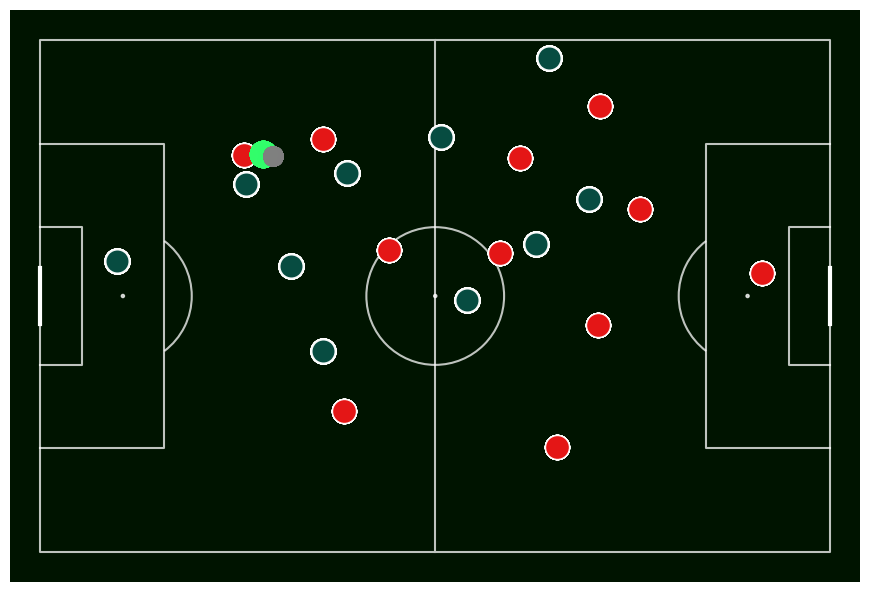

In [20]:
#synced["tip"] = synced.team_id_event == synced.team_id_tracking

pitch = Pitch(
    pitch_type="skillcorner",
    line_alpha=0.75,
    pitch_length=105,
    pitch_width=68,
    pitch_color="#001400",
    line_color="white",
    linewidth=1.5,
)
fig, ax = pitch.grid(figheight=8, endnote_height=0, title_height=0)

size = 300
possession_team = enriched_tracking_data[enriched_tracking_data.tip == True]
ax.scatter(
    possession_team["x"],
    possession_team["y"],
    c="#084D42",
    alpha=0.95,
    s=size,
    edgecolors="white",
    linewidths=1.5,
    zorder=10,
    label="team",
)

out_of_possession_team = enriched_tracking_data[enriched_tracking_data.tip == False]
ax.scatter(
    out_of_possession_team["x"],
    out_of_possession_team["y"],
    c="#E51717",
    alpha=0.95,
    s=size,
    edgecolors="white",
    linewidths=1,
    zorder=10,
    label="team",
)


ball_carrier = enriched_tracking_data[enriched_tracking_data.ball_carrier == True]
ax.scatter(
    ball_carrier["x"],
    ball_carrier["y"],
    c="#32FE6B",
    alpha=0.95,
    s=size,
    edgecolors="#32FE6B",
    linewidths=2.5,
    zorder=10,
    label="team",
)

b_size=150
ax.scatter(
    ball_carrier["ball_x"],
    ball_carrier["ball_y"],
    c="gray",
    alpha=0.95,
    s=b_size,
    edgecolors="gray",
    linewidths=2.5,
    zorder=10,
    label="team",
)

In [21]:
tracking_data_highest.loc[:0]

,true_value,predicted_class,predicted_probability,match_id,frame_start,frame_end,rec_player_id,prev_player_id,prev_player_name,rec_team_short,...,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,ball_y,ball_z
0,1,1,0.768135,1899585,36803.0,36803.0,133498,698137.0,I. Hughes,Auckland FC,...,285188,False,36803,2026-01-03 00:56:43.300,2.0,NaN,away team,-21.5,18.56,1.8


## Great example of low goal scoring recovery

In [22]:
tracking_data_lowest[['frame_start', 'team_out_of_possession_phase_type']].drop_duplicates()

,frame_start,team_out_of_possession_phase_type
0,23185.0,high_block
308,11469.0,high_block
330,387.0,high_block
396,10754.0,high_block
660,49312.0,high_block
946,47920.0,high_block
1056,10163.0,high_block
1166,47726.0,high_block
1342,1667.0,high_block
1364,9686.0,high_block


In [23]:
tracking_data_lowest = tracking_data_lowest.loc[tracking_data_lowest['frame_start'] == 11469.0]

tracking_data_lowest.reset_index(drop=True, inplace=True)

tracking_data_lowest['rec_player_id'] = tracking_data_lowest['rec_player_id'].astype(int)
tracking_data_lowest['match_id'] = tracking_data_lowest['match_id'].astype(int)

match_id = tracking_data_lowest.loc[0, 'match_id']

We are getting the meta data so we can distinguish between the team in possession and the opponent

In [24]:
def time_to_seconds(time_str):
    if time_str is None:
        return 90 * 60  # 120 minutes = 7200 seconds
    h, m, s = map(int, time_str.split(':'))
    return h * 3600 + m * 60 + s

file_path = f"../../data/matches/{match_id}/{match_id}_match.json"

with open(file_path, "r") as f:
    raw_match_data = json.load(f)

# The output has nested json elements. We process them
raw_match_df = pd.json_normalize(raw_match_data, max_level=2)
raw_match_df["home_team_side"] = raw_match_df["home_team_side"].astype(str)

players_df = pd.json_normalize(
    raw_match_df.to_dict("records"),
    record_path="players",
    meta=[
        "home_team_score",
        "away_team_score",
        "date_time",
        "home_team_side",
        "home_team.name",
        "home_team.id",
        "away_team.name",
        "away_team.id",
    ],  # data we keep
)


# Take only players who played and create their total time
players_df = players_df[
    ~((players_df.start_time.isna()) & (players_df.end_time.isna()))
]

# Create a flag for GK
players_df["is_gk"] = players_df["player_role.acronym"] == "GK"

# Add a flag if the given player is home or away
players_df["match_name"] = (
    players_df["home_team.name"] + " vs " + players_df["away_team.name"]
)


# Add a flag if the given player is home or away
players_df["home_away_player"] = np.where(
    players_df.team_id == players_df["home_team.id"], "Home", "Away"
)

# Create flag from player
players_df["team_name"] = np.where(
    players_df.team_id == players_df["home_team.id"],
    players_df["home_team.name"],
    players_df["away_team.name"],
)

# Figure out sides
players_df[["home_team_side_1st_half", "home_team_side_2nd_half"]] = (
    players_df["home_team_side"]
    .astype(str)
    .str.strip("[]")
    .str.replace("'", "")
    .str.split(", ", expand=True)
)
# Clean up sides
players_df["direction_player_1st_half"] = np.where(
    players_df.home_away_player == "Home",
    players_df.home_team_side_1st_half,
    players_df.home_team_side_2nd_half,
)
players_df["direction_player_2nd_half"] = np.where(
    players_df.home_away_player == "Home",
    players_df.home_team_side_2nd_half,
    players_df.home_team_side_1st_half,
)


# Clean up and keep the columns that we want to keep about

columns_to_keep = [
    "match_name",
    "home_team.name",
    "away_team.name",
    "id",
    "short_name",
    "team_id",
    "team_name",
    "player_role.position_group",
    "player_role.name",
    "player_role.acronym",
    "is_gk",
    "direction_player_1st_half",
    "direction_player_2nd_half",
]
players_df = players_df[columns_to_keep]

In [25]:
enriched_tracking_data = tracking_data_lowest.merge(
    players_df, left_on=["player_id"], right_on=["id"]
)

#enriched_tracking_data['rec_team_short'] = enriched_tracking_data['rec_team_short'] + ' ' + 'Football Club'
enriched_tracking_data['rec_team_short'] = enriched_tracking_data['rec_team_short'].str.replace('Wellington P FC', 'Wellington Phoenix FC')

enriched_tracking_data["ball_carrier"] = enriched_tracking_data.rec_player_id == enriched_tracking_data.player_id
enriched_tracking_data["tip"] = enriched_tracking_data.rec_team_short == enriched_tracking_data.team_name

enriched_tracking_data.head()

,true_value,predicted_class,predicted_probability,match_id,frame_start,frame_end,rec_player_id,prev_player_id,prev_player_name,rec_team_short,...,team_id,team_name,player_role.position_group,player_role.name,player_role.acronym,is_gk,direction_player_1st_half,direction_player_2nd_half,ball_carrier,tip
0,0,0,0.261169,1899585,11469.0,11487.0,26969,4322.0,H. Sakai,Wellington Phoenix FC,...,867,Wellington Phoenix FC,Other,Goalkeeper,GK,True,left_to_right,right_to_left,False,True
1,0,0,0.261169,1899585,11469.0,11487.0,26969,4322.0,H. Sakai,Wellington Phoenix FC,...,867,Wellington Phoenix FC,Central Defender,Center Back,CB,False,left_to_right,right_to_left,False,True
2,0,0,0.261169,1899585,11469.0,11487.0,26969,4322.0,H. Sakai,Wellington Phoenix FC,...,867,Wellington Phoenix FC,Central Defender,Right Center Back,RCB,False,left_to_right,right_to_left,False,True
3,0,0,0.261169,1899585,11469.0,11487.0,26969,4322.0,H. Sakai,Wellington Phoenix FC,...,867,Wellington Phoenix FC,Central Defender,Left Center Back,LCB,False,left_to_right,right_to_left,False,True
4,0,0,0.261169,1899585,11469.0,11487.0,26969,4322.0,H. Sakai,Wellington Phoenix FC,...,867,Wellington Phoenix FC,Full Back,Right Wing Back,RWB,False,left_to_right,right_to_left,False,True


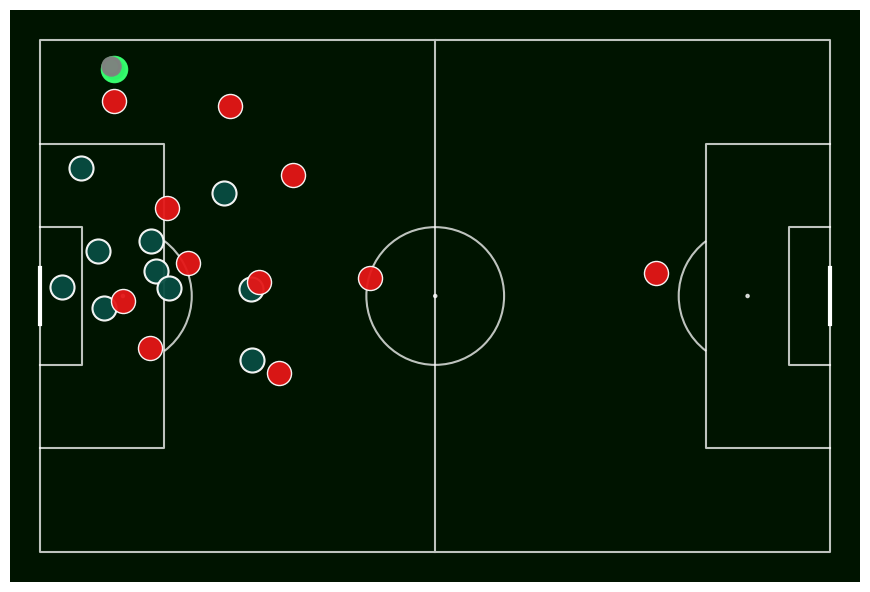

In [26]:
#synced["tip"] = synced.team_id_event == synced.team_id_tracking

pitch = Pitch(
    pitch_type="skillcorner",
    line_alpha=0.75,
    pitch_length=105,
    pitch_width=68,
    pitch_color="#001400",
    line_color="white",
    linewidth=1.5,
)
fig, ax = pitch.grid(figheight=8, endnote_height=0, title_height=0)

size = 300
possession_team = enriched_tracking_data[enriched_tracking_data.tip == True]
ax.scatter(
    possession_team["x"],
    possession_team["y"],
    c="#084D42",
    alpha=0.95,
    s=size,
    edgecolors="white",
    linewidths=1.5,
    zorder=10,
    label="team",
)

out_of_possession_team = enriched_tracking_data[enriched_tracking_data.tip == False]
ax.scatter(
    out_of_possession_team["x"],
    out_of_possession_team["y"],
    c="#E51717",
    alpha=0.95,
    s=size,
    edgecolors="white",
    linewidths=1,
    zorder=10,
    label="team",
)


ball_carrier = enriched_tracking_data[enriched_tracking_data.ball_carrier == True]
ax.scatter(
    ball_carrier["x"],
    ball_carrier["y"],
    c="#32FE6B",
    alpha=0.95,
    s=size,
    edgecolors="#32FE6B",
    linewidths=2.5,
    zorder=10,
    label="team",
)

b_size=150
ax.scatter(
    ball_carrier["ball_x"],
    ball_carrier["ball_y"],
    c="gray",
    alpha=0.95,
    s=b_size,
    edgecolors="gray",
    linewidths=2.5,
    zorder=10,
    label="team",
)